In [ ]:
# •	File name: Parametric idf model (data generation code)
# •	Author: Ehsan Akbari
# •	Affiliation: University of Waterloo, PhD student.

In [1]:
### Parameterize functions

from pathlib import Path
from subprocess import run, DEVNULL
import json
from shutil import copy, rmtree
import pandas as pd
from natsort import natsorted
import numpy as np
from itertools import product
from copy import deepcopy
import h5py

def convert_idf_to_epjson(
    original_idf_location: Path,
    output_path: Path,
    eplus_path: Path,
):
    """Convert idf to epjson and vice-versa. New version of EnergyPlus allow
    a --convert-only flag so that no simulation is run and no weather file is needed,
    but since we are dealing a lot with older versions, we will use the old method
    that requires the simulation to fully run.

    Args:
        original_idf_location (pathlib.Path): The location of the idf
        output_path (pathlib.Path): The output folder
        eplus_path (pathlib.Path): The folder of energyplus
    """
    # Create a new temporary folder for all EnergyPlus files
    temp_folder = output_path.joinpath("temp_folder")
    temp_folder.mkdir(exist_ok=True)

    # Create temperary file named temp.idf or .epjson, because some versions of
    # E+ cannot handle a dot (.) in the name
    copy(original_idf_location, temp_folder)
    # Now rename it to temp.idf or .epjson
    temp_file_path = temp_folder.joinpath(original_idf_location.name).with_stem("temp")
    # If the temp file already exists then delete it, it's a temp file after all
    if temp_file_path.exists():
        temp_file_path.unlink()
    temp_folder.joinpath(original_idf_location.name).rename(temp_file_path)
    # Create the EnergyPlus command to run
    eplus_exe = Path(eplus_path).joinpath("energyplus.exe")
    command = f"{eplus_exe} -d {temp_folder} -c"
    command = f"{command} {temp_file_path}"

    # We know that running energyplus without a weather file will throw an error,
    # but not before it converts the idf to epjson. That means that I can run it,
    # catch the exception and stop it there
    try:
        run(
            command, universal_newlines=True, check=True, stderr=DEVNULL, stdout=DEVNULL
        )
    except Exception:
        pass

    # Move the epJSON file to the output folder
    if temp_file_path.suffix == ".idf":
        file_to_move = temp_folder.joinpath(temp_file_path.name).with_suffix(".epJSON")
    elif temp_file_path.suffix == ".epJSON":
        file_to_move = temp_folder.joinpath(temp_file_path.name).with_suffix(".idf")
    copy(file_to_move.as_posix(), output_path)
    proper_name = output_path.joinpath(file_to_move.name).with_stem(
        original_idf_location.stem
    )
    # If the new idf exists, overwrite it
    if proper_name.exists():
        proper_name.unlink()
    output_path.joinpath(file_to_move.name).rename(proper_name)
    # Delete the temporary folder and the temporary file
    rmtree(temp_folder)


def read_epjson(epjson_path: Path | str) -> dict:
    """Get the epjson of the E+ version from specified folder.

    Args:
        folder_path (pathlib.Path | str): The folder of the E+ version.

    Returns:
        dict: The epJSON
    """
    epjson_path = Path(epjson_path)
    with open(epjson_path, "r", encoding="utf-8") as file:
        epjson_schema = json.load(file)
    return epjson_schema


def update_idf(
    original_idf_location: Path,
    output_path: Path,
    eplus_path: Path,
    old_version: str | None = None,
) -> dict:
    """Update the idf to the version of Energy+, convert it to epJSON and read it

    Args:
        original_idf_location (pathlib.Path): The original location of the idf
        output_path (pathlib.Path): The output folder
        eplus_path (pathlib.Path): The Energy+ folder
        old_version (str | None, optional): The version of the old idf. Defaults to None,
            in which case the script tries to convert the file to an epjson and read the version.

    Returns:
        dict: The epJSON
    """
    # Identify the folder that contains the IDF Version Updaters
    updater_folder = eplus_path.joinpath("PreProcess/IDFVersionUpdater")
    # Get the versions we can process
    versions = natsorted([file.stem[1:-8] for file in updater_folder.rglob("*.idd")])

    # If the version of the old file is not provided, try to convert the idf to epJSON and read
    # the version from there. Note that for very old version this will not work
    if not old_version:
        convert_idf_to_epjson(original_idf_location, output_path, eplus_path)
        epjson = read_epjson(
            output_path.joinpath(f"{original_idf_location.stem}.epJSON")
        )

        # Read the version of the file
        old_version = f"{epjson['Version']['Version 1']['version_identifier'].replace('.', '-')}-0"

    # Read the version of Energy+
    new_version = eplus_path.stem.split("V")[1]

    # If the versions are the same return the epJSON
    if old_version == new_version:
        return

    output_idf_location = output_path.joinpath(original_idf_location.name)
    old_index = versions.index(old_version)
    new_index = versions.index(new_version)

    # Unfortunately we need to run the updater for every version
    for version_index in range(old_index, new_index):
        transition_exe = (
            f"Transition-V{versions[version_index]}-to"
            f"-V{versions[version_index+1]}.exe"
        )
        command = updater_folder.joinpath(transition_exe)
        copy(original_idf_location.as_posix(), output_idf_location)
        final_command = f"{command} {output_idf_location}"
        run(final_command, universal_newlines=True, cwd=updater_folder, check=True)
    # Delete the two files that are created in the process with extensions .idfnew
    # and .idfold
    output_path.joinpath(f"{original_idf_location.name}new").unlink()
    output_path.joinpath(f"{original_idf_location.name}old").unlink()


def create_full_factorial(inputs: pd.DataFrame) -> pd.DataFrame:
    """Create all possible combinations of the parameters in the inputs dataframe

    Args:
        inputs (pd.DataFrame): The dataframe that includes the desired inputs

    Returns:
        pd.DataFrame: A dataframe that includes all possible combinations
    """
    # First create a dictionary with all possible values for each parameter
    parameter_values = {}
    for row_name, row in inputs.iterrows():
        parameter_values[row_name] = np.linspace(
            row["Min_value"], row["Max_value"], row["Number_samples"]
        )
    # Then return a dataframe that include the cartesian product of these values. The dataframe
    # has as many rows as combinations and as many columns as parameters
    full_factorial = pd.DataFrame(
        list(product(*parameter_values.values())), columns=parameter_values.keys()
    )
    return full_factorial.round(5)


def modify_idf(
    original_idf: dict, inputs: pd.DataFrame, combination: pd.Series
) -> dict:
    """Modify the original idf with the inputs and the combination

    Args:
        original_idf (dict): The original idf as a dictionary
        inputs (pd.DataFrame): The inputs from the inputs file
        combination (pd.Series): The combination of parameters we are modifying

    Returns:
        dict: The modified idf
    """
    # Make sure to deepcopy the original dictionary, otherwise the original will be modified as well
    modified_idf = deepcopy(original_idf)

    for parameter_label, parameter in inputs.iterrows():
        modified_idf[parameter["Class"]][parameter["Object"]][parameter["Field"]] = (
            combination[parameter_label]
        )

    return modified_idf


def save_idf(
    modified_idf: dict,
    output_path: Path,
    combination: pd.Series,
    eplus_path: Path,
    keep_epjson: bool = False,
) -> None:
    """Save the modified idf to a file

    Args:
        modified_idf (dict): The modified idf
        output_path (pathlib.Path): The output path
        combination (pd.Series): The combination of parameters we are modifying
        eplus_path (pathlib.Path): The folder of energyplus
        keep_epjson (bool, optional): Whether to keep the epJSON as well. Defaults to False.
    """

    # Create the name of the idf
    idf_name = f"{'_'.join(combination.values.astype(str))}.epJSON"
    # Save the dict as a json file
    with open(output_path.joinpath(idf_name), "w", encoding="utf-8") as file:
        json.dump(modified_idf, file, indent=4)

    # Now transform it to an idf using Energyplus
    convert_idf_to_epjson(output_path.joinpath(idf_name), output_path, eplus_path)

    # If we don't want to keep the epJSON, delete it
    if not keep_epjson:
        output_path.joinpath(idf_name).unlink()


def run_simulation(
    idf_location: Path,
    output_path: Path,
    epw_path: Path,
    eplus_path: Path,
):
    """Run the EnergyPluy simulation

    Args:
        idf_location (pathlib.Path): The location of the idf
        output_path (pathlib.Path): The output folder
        epw_path (pathlib.Path): The location of the weather file
        eplus_path (pathlib.Path): The folder of energyplus
    """

    # Create the folder name for the energyplus results
    output_folder = output_path.joinpath(f"{idf_location.stem}")
    eplus_exe = Path(eplus_path).joinpath("energyplus.exe")
    command = f"{eplus_exe} -d {output_folder} -w {epw_path} -r"
    command = f"{command} {idf_location}"
    run(command, universal_newlines=True, check=True)


In [2]:
### Functions that I created or edited
from scipy.stats import qmc  # For Latin Hypercube Sampling


import numpy as np
import pandas as pd
from scipy.stats import qmc

# def create_latin_hypercube_reference(inputs: pd.DataFrame, num_samples: int = None) -> pd.DataFrame:
#     """Generate LHS samples from a DataFrame with Label-indexed Min/Max values."""
#     parameter_values = {
#         label: (row["Min_value"], row["Max_value"])
#         for label, row in inputs.iterrows()
#     }
    
#     num_samples = num_samples or inputs["Number_samples"].min()
#     sampler = qmc.LatinHypercube(d=len(parameter_values))
#     sample = sampler.random(n=num_samples)
    
#     # Key Fix: Ensure 2D structure during scaling
#     scaled_samples = np.column_stack([
#         qmc.scale(sample[:, [i]], min_val, max_val).flatten()  # ← [i] keeps 2D shape
#         for i, (min_val, max_val) in enumerate(parameter_values.values())
#     ])
    
#     return pd.DataFrame(scaled_samples, columns=parameter_values.keys()).round(5)

def create_latin_hypercube(inputs: pd.DataFrame, num_samples: int = None) -> pd.DataFrame:
    """Generate parameter combinations using Latin Hypercube Sampling.
    
    Args:
        inputs (pd.DataFrame): Dataframe with the following structure:
            Index: Label (parameter names)
            Columns: Min_value, Max_value, Number_samples
        num_samples (int, optional): Number of LHS samples. Defaults to min(Number_samples).
    
    Returns:
        pd.DataFrame: Sampled parameter combinations with parameter names as columns
    """
    # Create parameter ranges dictionary using the index (Label)
    parameter_values = {
        label: (row["Min_value"], row["Max_value"])
        for label, row in inputs.iterrows()
    }
    
    # Determine number of samples
    if num_samples is None:
        num_samples = inputs["Number_samples"].min()
    
    # Generate LHS samples
    sampler = qmc.LatinHypercube(d=len(parameter_values))
    sample = sampler.random(n=num_samples)
    
    # Scale samples to parameter ranges
    scaled_samples = np.zeros_like(sample)
    for i, (param_name, (min_val, max_val)) in enumerate(parameter_values.items()):
        scaled_samples[:, i] = qmc.scale(sample[:, [i]], min_val, max_val).flatten()
    
    # Create DataFrame with parameter names as columns
    lhs_df = pd.DataFrame(scaled_samples, columns=parameter_values.keys())
    return lhs_df.round(5)



def modify_specific_vertices(
    epjson: dict,
    area: float,
    aspect_ratio: float,
    # Perimeter coordinates
    x1: float = 0, y1: float = 0,
    x2: float = 50, y2: float = 0,
    x3: float = 50, y3: float = 50,
    x4: float = 0, y4: float = 50,
    # Core coordinates
    cx1: float = 5, cy1: float = 5,
    cx2: float = 45, cy2: float = 5,
    cx3: float = 45, cy3: float = 45,
    cx4: float = 5, cy4: float = 45,
    object_class: str = "BuildingSurface:Detailed"
) -> dict:
    """
    Modifies ALL vertices matching target (x,y) pairs, including duplicates.
    Returns updated EPJSON.
    """
    modified = deepcopy(epjson)
    
    # Calculate scaling
    original_width = x2 - x1
    original_depth = y4 - y1
    scale_x = (area * aspect_ratio) ** 0.5 / original_width
    scale_y = (area / aspect_ratio) ** 0.5 / original_depth

    # Define transformations (original → new)
    point_transforms = [
        ((x1, y1), (x1 * scale_x, y1 * scale_y)),
        ((x2, y2), (x2 * scale_x, y2 * scale_y)),
        ((x3, y3), (x3 * scale_x, y3 * scale_y)),
        ((x4, y4), (x4 * scale_x, y4 * scale_y)),
        ((cx1, cy1), (x1*scale_x + (cx1-x1), y1*scale_y + (cy1-y1))),
        ((cx2, cy2), (x2*scale_x - (x2-cx2), y2*scale_y + (cy2-y2))),
        ((cx3, cy3), (x3*scale_x - (x3-cx3), y3*scale_y - (y3-cy3))),
        ((cx4, cy4), (x4*scale_x + (cx4-x4), y4*scale_y - (y4-cy4)))
    ]

    # Convert to a dictionary for faster lookup
    transform_map = {orig: new for orig, new in point_transforms}

    # Process ALL vertices
    for surface in modified.get(object_class, {}).values():
        for vertex in surface.get("vertices", []):
            vx = vertex["vertex_x_coordinate"]
            vy = vertex["vertex_y_coordinate"]
            
            # Check against all possible transforms
            for (orig_x, orig_y), (new_x, new_y) in transform_map.items():
                if (abs(vx - orig_x) < 1e-6 and abs(vy - orig_y) < 1e-6):
                    vertex["vertex_x_coordinate"] = new_x
                    vertex["vertex_y_coordinate"] = new_y
                    # NO BREAK - Continue checking other transforms
    
    return modified

def modify_window_vertices(
    epjson: dict,
    area: float,
    aspect_ratio: float,
    original_width: float = 50.0,
    original_depth: float = 50.0
) -> dict:
    """
    Correctly modifies window vertices while preserving original data types.
    Handles both string and numeric coordinate fields.
    """
    modified = deepcopy(epjson)
    
    # Calculate scaling factors
    scale_x = (area * aspect_ratio) ** 0.5 / original_width
    scale_y = (area / aspect_ratio) ** 0.5 / original_depth
    
    if "FenestrationSurface:Detailed" not in modified:
        print("⚠️ No windows found in the model")
        return modified
    
    for window in modified["FenestrationSurface:Detailed"].values():
        for i in range(1, 5):  # For each vertex
            x_key = f"vertex_{i}_x_coordinate"
            y_key = f"vertex_{i}_y_coordinate"
            
            try:
                # Store original type
                is_str = isinstance(window[x_key], str)
                
                # Convert to float, scale, and convert back to original type
                x_val = float(window[x_key]) * scale_x
                y_val = float(window[y_key]) * scale_y
                
                window[x_key] = str(x_val) if is_str else x_val
                window[y_key] = str(y_val) if is_str else y_val
                
            except (KeyError, ValueError) as e:
                print(f"⚠️ Error processing vertex {i}: {e}")
                continue
    
    return modified


def modify_window_heights(
    epjson: dict,
    wwr: float,
    h1: float = 1.4,
    reference_wwr: float = 0.35,
    target_zs: list = [2.2],  # Now accepts multiple z-values
    tolerance: float = 0.01
) -> dict:
    """
    Modifies window vertices at MULTIPLE z-levels using:
    new_z = current_z + (height_factor - 1) * h1
    
    Args:
        epjson: EPJSON dictionary
        wwr: New window-to-wall ratio (0-1)
        h1: Original window height (default 1.4m)
        reference_wwr: Baseline WWR (default 0.35)
        target_zs: List of z-coordinates to modify (default [2.2])
        tolerance: Allowed deviation from target z-values
        
    Returns:
        Modified EPJSON dictionary
    """
    modified = deepcopy(epjson)
    height_factor = wwr / reference_wwr
    
    if "FenestrationSurface:Detailed" not in modified:
        print("⚠️ No windows found in the model")
        return modified
    
    for window_name, window in modified["FenestrationSurface:Detailed"].items():
        for i in range(1, 5):  # Check all 4 vertices
            z_key = f"vertex_{i}_z_coordinate"
            
            try:
                current_z = float(window[z_key])
                # Check against ALL target z-values
                for target_z in target_zs:
                    if abs(current_z - target_z) <= tolerance:
                        new_z = current_z + (height_factor - 1)*h1
                        # Preserve original data type
                        window[z_key] = str(new_z) if isinstance(window[z_key], str) else new_z
                        break  # Stop checking other targets after first match
                        
            except (KeyError, ValueError) as e:
                print(f"⚠️ Skipping vertex {i} in window {window_name}: {str(e)}")
                continue
    
    return modified

In [3]:
import os
print("Current directory:", os.getcwd())  # Output: e.g., `/home/user/notebooks`

Current directory: C:\Users\User


In [5]:
# Change the directory
os.chdir("C:/Users/User/Documents/Me/parameterize_idfs")  # Change directory
#print("New directory:", os.getcwd())

In [11]:
### Postprocess results new
from pathlib import Path
import pandas as pd
import sqlite3

def read_results(modified_inputs: pd.DataFrame, 
                 results_folder_path: str | Path, 
                 from_source: str = "sql") -> pd.DataFrame:

    results_folder_path = Path(results_folder_path)
    energy_results = []
    # Iterate over the rows of the dataframe
    for _, row in modified_inputs.iterrows():
        # Define the name of the folder that you should look into
        #  (e.g., 1.136_0.3)
        idf_name = f"{'_'.join(row.values.astype(str))}"

        # Fetch the KPI you want and append it to the list
        if from_source == 'csv':
            energy_result = read_csv_result(
                results_folder_path.joinpath(f"{idf_name}/eplustbl.csv")
                )
        elif from_source == 'sql':
            energy_result = read_sql_result(
                results_folder_path.joinpath(f"{idf_name}/eplusout.sql")
                )
        energy_results.append(energy_result)

    # Now save the new data as a new column in the dataframe
    modified_inputs["EUI [MJ/m2]"] = energy_results
    return modified_inputs


# def read_csv_result(csv_file_path: str | Path) -> float:
#     """ Read results from the csv file

#         Args:
#         csv_file_path (str|Path): The path to the csv file
#     """
#     csv_file_path = Path(csv_file_path)
#     # The csv file is not very well formatted. Therefore, we can only read uniform parts of it that look
#     # like "tables". For example in this case we skip the first 13 rows and only read the table with
#     # the summary that also appears in the html file
#     data = pd.read_csv(csv_file_path, skiprows=13, nrows=4, usecols=[1, 2, 3, 4], index_col=0)
#     # Only return the total energy per conditioned area
#     return data.loc["Total Site Energy", "Energy Per Conditioned Building Area [MJ/m2]"]


# def read_sql_result(sql_file_path: str | Path) -> float:
#     """ Read results from the sql file

#         Args:
#         sql_file_path (str|Path): The path to the sql file
#     """
#     sql_file_path = Path(sql_file_path)
#     # Create a URI
#     sql_uri = '{}?mode=ro'.format(sql_file_path.as_uri())

#     # Define your query. This defined which data exactly you want to extract from the sql file
#     # The following query fetches all table names. Try running the following query and printing it
#     # query = "SELECT name FROM sqlite_master;"
#     # query = "SELECT * FROM TabularDataWithStrings WHERE ReportName='AnnualBuildingUtilityPerformanceSummary'"

#     facility_electricity_annual_peak = 0
#     heating_coils_energy_transfer = 0
#     baseboards_energy_transfer = 0

#     query = "SELECT * FROM ReportMeterDataDictionary"
#     # Establish the connection to the sql, run the query and save the results in a pandas dataframe
#     with sqlite3.connect(sql_uri, uri=True) as connection:
#         meter_dictionary = pd.read_sql(query, connection).loc[:, ["VariableName", "ReportMeterDataDictionaryIndex", "ReportingFrequency", "VariableUnits"]]

#     if "Electricity:Facility" in meter_dictionary["VariableName"].values:
#         query = f'SELECT MAX(VariableValue) FROM ReportMeterData WHERE ReportMeterDataDictionaryIndex={meter_dictionary.loc[meter_dictionary["VariableName"] == "Electricity:Facility", "ReportMeterDataDictionaryIndex"].astype(str).squeeze()}'

#         with sqlite3.connect(sql_uri, uri=True) as connection:
#             facility_electricity_annual_peak = pd.read_sql(query, connection).squeeze() * 2.77778e-7

#     query = f"SELECT SUM(VariableValue) FROM ReportMeterData WHERE ReportMeterDataDictionaryIndex in ({', '.join(meter_dictionary.loc[:, 'ReportMeterDataDictionaryIndex'].astype(str).to_list())}) GROUP BY ReportMeterDataDictionaryIndex" 
#     with sqlite3.connect(sql_uri, uri=True) as connection:
#         meter_dictionary["VariableValue"] = pd.read_sql(query, connection)

#     meter_dictionary = meter_dictionary.set_index("VariableName")["VariableValue"] * 2.77778e-7

#     query = "SELECT * FROM TabularDataWithStrings WHERE ReportName='AnnualBuildingUtilityPerformanceSummary'"
#     with sqlite3.connect(sql_uri, uri=True) as connection:
#         end_uses = pd.read_sql(query, connection)

#     meter_dictionary["eui"] = end_uses.loc[(end_uses.ColumnName=='Energy Per Total Building Area')&(end_uses.RowName=='Total Site Energy'), "Value"].astype(float).squeeze() * 0.277778 

#     if "HeatingCoils:EnergyTransfer" in meter_dictionary.index.values:
#         heating_coils_energy_transfer = meter_dictionary["HeatingCoils:EnergyTransfer"]
#     if "Baseboard:EnergyTransfer" in meter_dictionary.index:
#         baseboards_energy_transfer = meter_dictionary["Baseboard:EnergyTransfer"]
#     meter_dictionary["tedi"] = (baseboards_energy_transfer + heating_coils_energy_transfer) / end_uses.loc[(end_uses.RowName=='Total Building Area'), "Value"].astype(float).squeeze()
#     meter_dictionary["electricity_facility_annual_peak"] = facility_electricity_annual_peak
#     meter_dictionary["unmet_hours_heating"] = end_uses.loc[end_uses.RowName=='Time Setpoint Not Met During Occupied Heating', "Value"].astype(float).squeeze()
#     meter_dictionary["unmet_hours_cooling"] = end_uses.loc[end_uses.RowName=='Time Setpoint Not Met During Occupied Cooling', "Value"].astype(float).squeeze()

#     # print(end_uses)
#     # Calculate or fetch the metric you want
#     # eui = end_uses.loc[(end_uses.ColumnName=='Energy Per Total Building Area')&(end_uses.RowName=='Total Site Energy'), "Value"].astype(float).squeeze()
#     return meter_dictionary


In [13]:
### My edit on Post processing functions:
import sqlite3
import pandas as pd
from pathlib import Path

def read_sql_result(sql_file_path: str | Path) -> dict:
    sql_file_path = Path(sql_file_path)
    sql_uri = f"{sql_file_path.as_uri()}?mode=ro"

    results = {}

    with sqlite3.connect(sql_uri, uri=True) as connection:
        query = "SELECT ReportName, TableName, RowName, ColumnName, Value FROM TabularDataWithStrings"
        tabular = pd.read_sql(query, connection)

    # --- Coil EnergyTransfer: Annual Value [GJ] ---
    coil_annual = (
        tabular[
            (tabular["ReportName"] == "EnergyMeters") &
            (tabular["TableName"] == "Annual and Peak Values - Other") &
            (tabular["RowName"].isin(["CoolingCoils:EnergyTransfer", "HeatingCoils:EnergyTransfer"])) &
            (tabular["ColumnName"].str.contains("Annual Value", case=False, na=False))
        ]
        .set_index("RowName")["Value"]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
    )

    # --- Extract Total Building Area ---
    with sqlite3.connect(sql_uri, uri=True) as connection:
        area_df = pd.read_sql(
            "SELECT * FROM TabularDataWithStrings WHERE ReportName='AnnualBuildingUtilityPerformanceSummary' AND TableName='Building Area'",
            connection
        )

    total_area = (
        area_df.loc[
            area_df.RowName == 'Total Building Area',
            "Value"
        ]
        .astype(float)
        .squeeze()
    )

    # Avoid division by zero
    if total_area == 0 or pd.isna(total_area):
        total_area = 1.0

    # --- Normalize Coil EnergyTransfer by Area (convert from GJ/m² to kWh/m²) ---
    GJ_to_kWh = 277.78  # 1 GJ = 277.78 kWh

    results["CEDI (kWh/m2)"] = float(coil_annual.get("CoolingCoils:EnergyTransfer", 0.0)) / total_area * GJ_to_kWh
    results["TEDI (kWh/m2)"] = float(coil_annual.get("HeatingCoils:EnergyTransfer", 0.0)) / total_area * GJ_to_kWh

    # --- Energy Use Intensity (kWh/m²) ---
    with sqlite3.connect(sql_uri, uri=True) as connection:
        end_uses_all = pd.read_sql(
            "SELECT * FROM TabularDataWithStrings WHERE ReportName='AnnualBuildingUtilityPerformanceSummary'",
            connection
        )

    eui_val = (
        end_uses_all.loc[
            (end_uses_all.ColumnName == 'Energy Per Total Building Area') &
            (end_uses_all.RowName == 'Total Site Energy'),
            "Value"
        ]
        .astype(float)
        .squeeze()
    )

    results["EUI (kWh/m2)"] = eui_val / 3.6  # Convert MJ/m² → kWh/m²

    return results

## following code is the same as upper one but has more outputs and CoolingCoils:EnergyTransfer,and HeatingCoils:EnergyTransfer are not turned to TEDI and CEDI
# def read_sql_result(sql_file_path: str | Path) -> dict:
#     sql_file_path = Path(sql_file_path)
#     sql_uri = '{}?mode=ro'.format(sql_file_path.as_uri())

#     results = {}

#     with sqlite3.connect(sql_uri, uri=True) as connection:
#         query = "SELECT ReportName, TableName, RowName, ColumnName, Value FROM TabularDataWithStrings"
#         tabular = pd.read_sql(query, connection)

#     ### --- End Uses: Electricity [GJ] ---
#     end_uses = (
#         tabular[
#             (tabular["ReportName"] == "AnnualBuildingUtilityPerformanceSummary") &
#             (tabular["TableName"] == "End Uses") &
#             (tabular["ColumnName"] == "Electricity")
#         ]
#         .set_index("RowName")["Value"]
#         .apply(pd.to_numeric, errors="coerce")
#         .fillna(0.0)
#     )

#     mapping = {
#         "Heating": "elec_heating",
#         "Cooling": "elec_cooling",
#         "Interior Lighting": "elec_lighting",
#         "Interior Equipment": "elec_equipment",
#         "Fans": "elec_fans",
#         "Total End Uses": "elec_total"
#     }
#     for row_name, key in mapping.items():
#         results[key] = float(end_uses.get(row_name, 0.0))

#     ### --- Coil EnergyTransfer: Annual Value [GJ] ---
#     coil_annual = (
#         tabular[
#             (tabular["ReportName"] == "EnergyMeters") &
#             (tabular["TableName"] == "Annual and Peak Values - Other") &
#             (tabular["RowName"].isin(["CoolingCoils:EnergyTransfer", "HeatingCoils:EnergyTransfer"])) &
#             (tabular["ColumnName"].str.contains("Annual Value", case=False, na=False))
#         ]
#         .set_index("RowName")["Value"]
#         .apply(pd.to_numeric, errors="coerce")
#         .fillna(0.0)
#     )

#     results["CoolingCoils:EnergyTransfer"] = float(coil_annual.get("CoolingCoils:EnergyTransfer", 0.0))
#     results["HeatingCoils:EnergyTransfer"] = float(coil_annual.get("HeatingCoils:EnergyTransfer", 0.0))

#     ##### --- Optional: Other KPIs (uncomment if needed) ---
#     with sqlite3.connect(sql_uri, uri=True) as connection:
#         end_uses_all = pd.read_sql(
#             "SELECT * FROM TabularDataWithStrings WHERE ReportName='AnnualBuildingUtilityPerformanceSummary'",
#             connection
#         )
    
#     ### Energy Use Intensity (MJ/m² or kWh/m² depending on units)
#     eui_val = (
#         end_uses_all.loc[
#             (end_uses_all.ColumnName == 'Energy Per Total Building Area') &
#             (end_uses_all.RowName == 'Total Site Energy'),
#             "Value"
#         ]
#         .astype(float)
#         .squeeze()
#     )
#     results["EUI (KW/m2)"] = eui_val/3.6
    
#     ### Unmet Hours Heating/Cooling
#     results["unmet_hours_heating"] = end_uses_all.loc[
#         end_uses_all.RowName == 'Time Setpoint Not Met During Occupied Heating',
#         "Value"
#     ].astype(float).squeeze()
    
#     results["unmet_hours_cooling"] = end_uses_all.loc[
#         end_uses_all.RowName == 'Time Setpoint Not Met During Occupied Cooling',
#         "Value"
#     ].astype(float).squeeze()
    
#     # TEDI example (HeatingCoils + Baseboards) per m²
#     # results["tedi"] = (results.get("HeatingCoils:EnergyTransfer", 0.0) + baseboards_energy_transfer) / total_area

#     return results



import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pandas")

# def read_csv_result(csv_file_path: str | Path):
#     """
#     Reads hourly results from an EnergyPlus CSV file and extracts
#     'Whole Building:Facility Net Purchased Electricity Energy [J](Hourly)'
#     as a pandas Series of 8760 values.
#     """
#     csv_file_path = Path(csv_file_path)

#     # Read the CSV file
#     data = pd.read_csv(csv_file_path, skip_blank_lines=True)
#     data.columns = data.columns.str.strip()

#     # Parse Date/Time using known format (fast, no warnings)
#     if "Date/Time" in data.columns:
#         data["Date/Time"] = pd.to_datetime(
#             data["Date/Time"], format="%m/%d  %H:%M:%S", errors="coerce"
#         )

#     # Extract the hourly electricity data
#     target_col = "Whole Building:Facility Net Purchased Electricity Energy [J](Hourly)"
#     if target_col not in data.columns:
#         raise KeyError(f"Column '{target_col}' not found in {csv_file_path}")

#     # Return just the hourly values (8760 rows)
#     return data[target_col].astype(float).reset_index(drop=True)

def read_csv_result(csv_path):
    """Read EnergyPlus hourly data from eplusout.csv and return 1D NumPy array (8760 values)."""
    try:
        data = pd.read_csv(csv_path)

        # Convert Date/Time safely (suppress warnings and speed up)
        if "Date/Time" in data.columns:
            data["Date/Time"] = pd.to_datetime(
                data["Date/Time"], format="%m/%d  %H:%M:%S", errors="coerce"
            )

        # Assuming the last column holds the numeric results
        hourly_values = data.iloc[:, -1]

        # Explicitly convert to NumPy array of floats
        hourly_values = hourly_values.to_numpy(dtype=float)

        return hourly_values

    except Exception as e:
        print(f"⚠️ Error reading {csv_path.name}: {e}")
        return np.array([])

In [23]:
import pathlib
import pandas as pd
import multiprocessing


# Step 0.1: Specify some constants for the script
ENERGY_PLUS_FOLDER = pathlib.Path("C:/EnergyPlusV25-1-0")  # The path to the folder of energy plus
IDF_PATH = pathlib.Path(".").absolute().joinpath("inputs/VRF_Plus_ERV_V06.idf")  # The location of the idf file
EPW_PATH = pathlib.Path(".").absolute().joinpath("inputs/CAN_ON_Region.of.Waterloo.Intl.AP.713680_TMYx.2007-2021.epw")  # The location of the epw file
OUTPUT_PATH = pathlib.Path(".").absolute().joinpath("output")
OUTPUT_CV_FILE_NAME = "dataout.csv"
OUTPUT_CV_FILE_NAME_hourly="dataout_hourly.csv"
######################################################################################################
PARALLEL = True
NUMBER_CPUS = multiprocessing.cpu_count() - 4
#####################################################################################################
INPUTS_FILE = pathlib.Path(".").absolute().joinpath("inputs/inputs.csv")
Test_input=pathlib.Path(".").absolute().joinpath("inputs/Test_inputs.csv")

# Step 0.2: Create a folder structure for secondary files and output files
OUTPUT_PATH.mkdir(exist_ok=True)  # Create the output folder. Don't throw an error if it already exists
idf_output_path = OUTPUT_PATH.joinpath("idf_files")
idf_output_path.mkdir(exist_ok=True)
results_path = OUTPUT_PATH.joinpath("results")
results_path.mkdir(exist_ok=True)
# updater_path = OUTPUT_PATH.joinpath("updater")
# updater_path.mkdir(exist_ok=True) # Create the updater folder. Don't throw an error if it already exists

In [25]:

# Step 1: Read the idf and the inputs. Update the idf if needed.
# parameterize_functions.update_idf(IDF_PATH, updater_path, ENERGY_PLUS_FOLDER, OLD_VERSION)

convert_idf_to_epjson(IDF_PATH, OUTPUT_PATH, ENERGY_PLUS_FOLDER)
idf = read_epjson(OUTPUT_PATH.joinpath(f"{IDF_PATH.stem}.epJSON"))

simulation_parameters = pd.read_csv(INPUTS_FILE, index_col="Label")
# The epJSON schema takes field names without any spaces or dahes, but with underscores
# and all lowercase. So we need to modify the field names to match the schema
simulation_parameters["Field"] = (simulation_parameters["Field"].str.replace(" |-", "_", regex=True).str.lower())


In [27]:
# Step 2: Modify the idf with the inputs and save each idf in one folder with a special name
simple_mask = simulation_parameters["Type"] == "simple"
geometry_mask = simulation_parameters["Type"] == "geometry"
# modified_inputs = create_full_factorial(simulation_parameters)

# Generate LHS samples for ALL parameters together
# modified_inputs = create_latin_hypercube(simulation_parameters,2600)
modified_inputs = pd.read_csv('C:/Users/User/Documents/Me/parameterize_idfs/inputs/Test_inputs.csv', encoding='latin-1')   
modified_inputs = pd.DataFrame(modified_inputs)

# ## Modify "N_of_Fl" values to natural numbers before saving
# if "N_of_Fl" in modified_inputs.columns:
#     # Round up to nearest natural number, replace 0 with 1
#     modified_inputs["N_of_Fl"] = np.ceil(modified_inputs["N_of_Fl"])
#     # Replace any 0 values with 1 (in case ceil(0) = 0)
#     modified_inputs["N_of_Fl"] = modified_inputs["N_of_Fl"].replace(0, 1)

### Costa ode for turning N_of_Fl to integers:
if "N_of_Fl" in modified_inputs.columns:
    modified_inputs["N_of_Fl"] = (
        pd.to_numeric(modified_inputs["N_of_Fl"], errors="coerce")
        .fillna(1)                # replace non-numeric with 1
        .pipe(np.ceil)             # round up
        .clip(lower=1)             # force minimum = 1
        .astype(int)               # cast to int type
    )

modified_inputs.to_csv(OUTPUT_PATH.joinpath("modified_inputs.csv"))  # Save a csv with all the inputs

# Split samples after generation
geometry_samples = modified_inputs[simulation_parameters[geometry_mask].index]
simple_samples = modified_inputs[simulation_parameters[simple_mask].index]
# Save and process both types
geometry_samples.to_csv(OUTPUT_PATH.joinpath("geometry_samples.csv"))
simple_samples.to_csv(OUTPUT_PATH.joinpath("simple_samples.csv"))

# 3. Get parameter names for each type
# geometry_params = simulation_parameters[geometry_mask].index.tolist()
# simple_params = simulation_parameters[simple_mask].index.tolist()

# Iterate through aligned parameter combinations
for idx in modified_inputs.index:
    # Get both parameter sets for this simulation case
    geo_row = geometry_samples.loc[idx]
    simple_row = simple_samples.loc[idx]
    # modified_idf = modify_specific_vertices(idf, row["Area"], row["Aspect_Ratio"])
    modified_idf = modify_specific_vertices(
        idf,  # Your loaded EPJSON dictionary
        geo_row["Area"],        # New area in m²
        geo_row["Aspect_Ratio"], # New aspect ratio
        # Optional coordinate overrides (defaults shown):
        x1=0, y1=0,       # Bottom-left perimeter
        x2=50, y2=0,      # Bottom-right perimeter
        x3=50, y3=50,     # Top-right perimeter
        x4=0, y4=50,      # Top-left perimeter
        cx1=5, cy1=5,     # Core bottom-left
        cx2=45, cy2=5,    # Core bottom-right
        cx3=45, cy3=45,   # Core top-right
        cx4=5, cy4=45     # Core top-left
    )
    modified_idf = modify_window_vertices(
        modified_idf,
        geo_row["Area"],        # New area
        geo_row["Aspect_Ratio"], # New aspect ratio
        original_width=50,# Original dimensions if different
        original_depth=50
    )

    # Modify WWR:
    modified_idf =modify_window_heights(
        modified_idf,
        wwr=geo_row["WWR"],
        h1=1.4,
        target_zs=[2.2, 6.2, 10.2]  
   )
    
    #Apply simple parameter modifications
    modified_idf = modify_idf(
        modified_idf, 
        simulation_parameters[simple_mask], 
        simple_row
    )
    modified_idf["ZoneGroup"]["Mid_Floor"]["zone_list_multiplier"] = int(modified_idf["ZoneGroup"]["Mid_Floor"]["zone_list_multiplier"])
    save_idf(modified_idf, idf_output_path, modified_inputs.loc[idx], ENERGY_PLUS_FOLDER)
    


In [29]:
# Step 3: Run the simulations

for idf_file in idf_output_path.iterdir():
    run_simulation(idf_file, results_path, EPW_PATH, ENERGY_PLUS_FOLDER)

In [30]:
 # Step 4: Post-process the results
## 0- saving annual results form sql file:

results = {}
for sql_path in OUTPUT_PATH.rglob("*.sql"):
    results[sql_path.parents[0].stem] = read_sql_result(
        sql_path.absolute()
    )
pd.DataFrame.from_dict(results, orient="index").fillna(0).to_csv(
    OUTPUT_CV_FILE_NAME
    )

In [34]:
 # continue of Step 4: Post-process the results - saving hourly results as 3D structure output
import h5py
# 1. Define paths and parameters
# ------------------------
OUTPUT_PATH = pathlib.Path(".").absolute().joinpath("output")
H5_FILE = OUTPUT_PATH.joinpath("hourly_data_3d.h5")
CSV_MAP_FILE = OUTPUT_PATH.joinpath("input_parameters.csv")

# Your parameter names in order:
PARAM_NAMES = [
    "Area", "Aspect_Ratio", "Window_U", "Window_SHGC", "Direction",
    "Wall_R", "Roof_R", "Infiltration", "WWR", "LPD", "EPD", "N_of_Fl"
]


# ------------------------
# 2. Collect all simulation data
# ------------------------
output_3d = []
sim_ids = []

for sql_path in OUTPUT_PATH.rglob("*.sql"):
    sim_folder = sql_path.parent
    sim_id = sim_folder.stem  # e.g., "600.0_0.3_1.0_0.7_0.0_0.29_0.03_0.0003_0.15_8.0_3.0_10.0"
    csv_path = sim_folder.joinpath("eplusout.csv")

    if csv_path.exists():
        hourly_values = read_csv_result(csv_path)
        if len(hourly_values) == 8760:
            hourly_2d = hourly_values.reshape((365, 24))
            output_3d.append(hourly_2d)
            sim_ids.append(sim_id)
        else:
            print(f"⚠️ Skipping {sim_id}: unexpected length ({len(hourly_values)})")
    else:
        print(f"⚠️ No eplusout.csv found for {sim_id}")

# ------------------------
# 3. Convert to 3D array and save efficiently
# ------------------------
if not output_3d:
    raise ValueError("❌ No valid simulation data found. Check file paths.")

output_3d = np.stack(output_3d, axis=0)  # Shape: (N_sim, 365, 24)

# Save as HDF5 file (optimized for large arrays)
with h5py.File(H5_FILE, "w") as f:
    f.create_dataset("hourly_data", data=output_3d, compression="gzip")
print(f"✅ Saved 3D hourly dataset to {H5_FILE} (shape={output_3d.shape})")

# ------------------------
# 4. Save input parameter mapping
# ------------------------
# Split folder names (e.g. "600.0_0.3_1.0_...") into numeric columns
param_values = [list(map(float, s.split("_"))) for s in sim_ids]

# Create DataFrame with proper column names
input_param_df = pd.DataFrame(param_values, columns=PARAM_NAMES)
input_param_df["SimID"] = sim_ids  # Keep a reference for traceability

# Save to CSV
input_param_df.to_csv(CSV_MAP_FILE, index=False)
print(f"✅ Saved parameter mapping to {CSV_MAP_FILE}")

✅ Saved 3D hourly dataset to C:\Users\User\Documents\Me\parameterize_idfs\output\hourly_data_3d.h5 (shape=(21, 365, 24))
✅ Saved parameter mapping to C:\Users\User\Documents\Me\parameterize_idfs\output\input_parameters.csv


Shape: (365, 24)
[[9.93324213e+07 1.01224216e+08 1.07529816e+08 1.04775435e+08
  1.03597471e+08]
 [9.77164658e+07 9.02805022e+07 1.16963487e+08 1.14164785e+08
  1.33610715e+08]
 [9.69317403e+07 9.60620315e+07 1.11101936e+08 1.04749538e+08
  1.15372194e+08]
 [9.50035907e+07 1.01245903e+08 1.19958908e+08 1.15268495e+08
  1.35816445e+08]
 [1.21426924e+08 1.16626658e+08 1.48770170e+08 1.39905546e+08
  1.50121484e+08]]


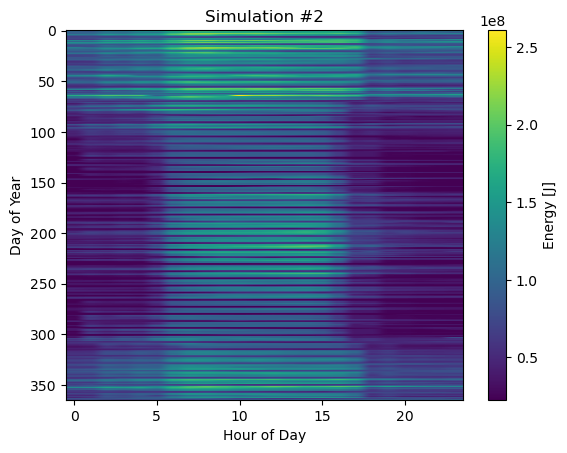

In [83]:
# Choose which simulation you want to see
import matplotlib.pyplot as plt
sim_index = 2  # e.g. first simulation

# Extract the 2D matrix (365 days × 24 hours)
one_sim_2d = output_3d[sim_index, :, :]

# Print a small part of it
print("Shape:", one_sim_2d.shape)
print(one_sim_2d[:5, :5])  # print first 5 days × 5 hours

# (Optional) Visualize as a heatmap
plt.imshow(one_sim_2d, aspect='auto', cmap='viridis')
plt.colorbar(label='Energy [J]')
plt.xlabel("Hour of Day")
plt.ylabel("Day of Year")
plt.title(f"Simulation #{sim_index}")
plt.show()

In [46]:
output_3d.shape

(84, 365, 24)